# Frozen v14/v15/v16 seed-1 100k qualification comparison and RCA

## TL;DR

- This notebook reads only the three frozen qualification runs and applies the exact population predicate `70000 < real_step <= 100000`; terminal overshoots 100112 (v14), 100736 (v15), and 100432 (v16) are excluded.
- Support-weighted held-out EMA selected-action TD RMSE is **0.5247954789** (v14, N=7,703), **0.5637126652** (v15, N=8,154), and **0.6433996229** (v16, N=7,535), each above the unchanged `<= 0.5` ceiling.
- V16 has a second CSV-observable hard-gate failure: five of 48 eligible trailing-five endpoints have **zero positive-sign support**, at steps 95344, 96368, 97392, 98416, and 99408. The other 43 endpoints are defined and positive; the zero-support endpoints are undefined, not negative.
- V16 is temporally uneven: W1 RMSE is 0.4241221974, while W2 and W3 are 0.9513859414 and 0.8161048403. Its pooled EMA SSE is 3,119.2118 against a threshold budget of 1,883.75.
- V16 W3 acceptance sign support is only **1 positive / 11,722 negative**. Its logged raw VoC-Q norm exceeds the unchanged nominal clip boundary 1,608 on **35/250** all-CSV rows and **7/52** canonical rows (v15: 1/149 and 0/58; v14: 0/204 and 0/63).
- The three runs are single-seed, separately generated, policy-coupled trajectories. Comparisons below are descriptive evidence, not causal attribution, a pass prediction, or authorization to launch/evaluate/retry/implement another version.


## Context & Methods

**Scope.** The only numeric inputs are frozen `logs.csv` and `logs_model.csv` files under the immutable v14/v15/v16 snapshots. Exact file hashes, protocol-document hashes, and launch-provenance hashes are asserted before analysis. The launch provenance also binds snapshot, XPID, production interpreter, and source/data manifest hashes. No checkpoint is loaded and no training, evaluation, fixed evaluation, retry, resume, or environment action is invoked.

**Protocol population.** Rows remain in CSV order and must be complete, finite, unique, and strictly increasing in `real_step`. Canonical qualification rows satisfy the strict predicate `70000 < real_step <= 100000`; windows are W1 `(70000,80000]`, W2 `(80000,90000]`, and W3 `(90000,100000]`. Overshoot is excluded rather than clipped, paired, interpolated, or replaced.

**Pooling.** A mean is `sum(row_support * row_value) / sum(row_support)`. RMSE is `sqrt(sum(row_support * row_rmse**2) / sum(row_support))`. Trailing-five student gaps pool positive and negative sufficient statistics independently over each five-row window. A missing sign denominator fails the denominator-validity gate; exactly zero gap is nonnegative.

**Interpretive boundary.** Window, split, composition, residual-moment, concentration, and update-norm summaries are observational diagnostics. Row-level bias/variance is an algebraic decomposition of logged held-out sufficient statistics, not a statistical bias-variance decomposition across replicated models. Event-level residual quantiles cannot be reconstructed from row aggregates.


In [1]:
from pathlib import Path
import csv
import hashlib
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PRODUCTION_PYTHON = Path('/home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python')
VERSIONS = {
    'v14': {
        'snapshot': Path('/tmp/di-voc-v14-sealed-eps25-final-eKgdrk'),
        'xpid': 'enduro-voc-v14-sealed-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8',
        'actor_shape': (204, 922),
        'model_sha256': 'b38dfd254fab250394ca463c4371c573b8c37f332e5f5f0b43c6d9b5fbfc3f64',
        'model_shape': (230, 52),
        'launch': Path('/tmp/v14qual100-hZGppv/launch_provenance.txt'),
        'launch_sha256': '0e9f4ad97ea5774ccc579da43118546b1c837d6e21ceaa3b9be8d7d330af5b54',
        'protocol_rel': 'src/VOC_V14_SEALED_MODEL_INPUT_300K_ACCEPTANCE.md',
        'protocol_sha256': 'f422089ec4df7479f89477a3e6e63744dc74d06d1ceab9d5ea10397b34500972',
        'source_manifest_sha256': '4fa507706250f349acfb6034453f1e8c70681c54e9e52718d848cd81755dbfea',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 63, 'first': 70032, 'last': 99376, 'support': 7703, 'overshoot': [100112]},
    },
    'v15': {
        'snapshot': Path('/tmp/di-voc-v15-halfsq-eps25-final-CKcYfI'),
        'xpid': 'enduro-voc-v15-halfsq-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d67800f0308f448e341',
        'actor_shape': (149, 922),
        'model_sha256': '360e6d475d635f734e4b14ddfff7a0022ba7997131785ce2ee7a39ea28b6839b',
        'model_shape': (189, 52),
        'launch': Path('/tmp/v15qual-JhNlYp/launch_provenance.txt'),
        'launch_sha256': 'ad1e625579aad7e9c400a4a85130939400ed1e0696b8c71987ce8e3bbfda9ccd',
        'protocol_rel': 'src/VOC_V15_HALF_SQUARED_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': 'cf5838f577ac55db2990669ebfd712c6cbbeee28e8b5388075833b69f4206b90',
        'source_manifest_sha256': '1c2d619479a63d75f0b23c41ef293f611b3631432356067a2db425a30ec62cdf',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 58, 'first': 70240, 'last': 99920, 'support': 8154, 'overshoot': [100736]},
    },
    'v16': {
        'snapshot': Path('/tmp/di-voc-v16-commonmode-eps25-final-mZ6A2C'),
        'xpid': 'enduro-voc-v16-commonmode-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '45da4532357f5f150fad15c47bf1cdbb5ec52738ff3a68678afb5dca73ed20d5',
        'actor_shape': (250, 922),
        'model_sha256': 'ef5e39aba9ad5b7c0c2b4bef34ba91bb6f3adf1bcdc940abe9915504b8b18225',
        'model_shape': (276, 52),
        'launch': Path('/tmp/v16qual-G3LwWW/launch_provenance.txt'),
        'launch_sha256': '1b712c604387725ccdc4aa1dbdcb016f4b4cb5c9b0effa22f150e27daf035325',
        'protocol_rel': 'src/VOC_V16_COMMON_MODE_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': '1814d68f667748358746c42f4578e17acbb950e9e0adac04a8d78c9352fdb84c',
        'source_manifest_sha256': 'f90b970c647b06884f1101a3b39d862eed97aec51d69013614b6b671f54112ea',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 52, 'first': 70032, 'last': 99408, 'support': 7535, 'overshoot': [100432]},
    },
}
for spec in VERSIONS.values():
    run_dir = spec['snapshot'] / 'runs' / spec['xpid']
    spec['actor_csv'] = run_dir / 'logs.csv'
    spec['model_csv'] = run_dir / 'logs_model.csv'
    spec['protocol'] = spec['snapshot'] / spec['protocol_rel']

WINDOWS = (('W1', 70000, 80000), ('W2', 80000, 90000), ('W3', 90000, 100000))
LOWER_STEP, UPPER_STEP, RMSE_CEILING = 70000, 100000, 0.5
COLORS = {'v14': '#2F6BFF', 'v15': '#F59E0B', 'v16': '#D946EF'}
rendered_figure_count = 0

assert sys.version_info[:3] == (3, 10, 21), sys.version
assert Path(sys.executable).resolve() == PRODUCTION_PYTHON.resolve(), sys.executable
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.18, 'font.size': 9})
print(f'Python {platform.python_version()} | {sys.executable}')
print(f'pandas={pd.__version__}, numpy={np.__version__}, matplotlib={plt.matplotlib.__version__}')


Python 3.10.21 | /home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python
pandas=2.3.3, numpy=1.26.4, matplotlib=3.10.9


## Data validation

The next cell fails closed on any byte drift, schema drift, incomplete actor row, non-finite actor numeric cell, non-integral/nonmonotone actor step, population mismatch, or provenance mismatch. `logs_model.csv` is hash/shape/schema bound but is not used to substitute any actor sufficient statistic. Its repeated/asynchronous `real_step` values are therefore not treated as actor qualification rows.


In [2]:
def sha256_file(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1 << 20), b''):
            digest.update(block)
    return digest.hexdigest()

def parse_provenance(path):
    return dict(line.split('=', 1) for line in path.read_text(encoding='utf-8').splitlines() if '=' in line)

frames, canonical, actor_headers, model_headers = {}, {}, {}, {}
quality_rows = []
for version, spec in VERSIONS.items():
    for key in ('actor_csv', 'model_csv', 'launch', 'protocol'):
        assert spec[key].is_file(), spec[key]
    actor_hash = sha256_file(spec['actor_csv'])
    model_hash = sha256_file(spec['model_csv'])
    launch_hash = sha256_file(spec['launch'])
    protocol_hash = sha256_file(spec['protocol'])
    assert actor_hash == spec['actor_sha256'], (version, 'actor', actor_hash)
    assert model_hash == spec['model_sha256'], (version, 'model', model_hash)
    assert launch_hash == spec['launch_sha256'], (version, 'launch', launch_hash)
    assert protocol_hash == spec['protocol_sha256'], (version, 'protocol', protocol_hash)
    with spec['actor_csv'].open('r', encoding='utf-8', newline='') as handle:
        actor_header = next(csv.reader(handle))
    with spec['model_csv'].open('r', encoding='utf-8', newline='') as handle:
        model_header = next(csv.reader(handle))
    assert len(actor_header) == len(set(actor_header)) == 922
    assert len(model_header) == len(set(model_header)) == 52
    frame = pd.read_csv(spec['actor_csv'])
    model_frame = pd.read_csv(spec['model_csv'])
    assert frame.shape == spec['actor_shape'], (version, frame.shape)
    assert model_frame.shape == spec['model_shape'], (version, model_frame.shape)
    assert list(frame.columns) == actor_header and list(model_frame.columns) == model_header
    assert frame.notna().all(axis=1).all(), version
    numeric = frame.select_dtypes(include=[np.number])
    assert numeric.shape[1] == 917 and np.isfinite(numeric.to_numpy(dtype=np.float64)).all()
    steps = pd.to_numeric(frame['real_step'], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(steps).all() and np.equal(steps, np.rint(steps)).all()
    assert np.all(np.diff(steps) > 0) and frame.real_step.is_unique
    population = frame.loc[(frame.real_step > LOWER_STEP) & (frame.real_step <= UPPER_STEP)].copy().reset_index(drop=True)
    overshoot = frame.loc[frame.real_step > UPPER_STEP, 'real_step'].astype(int).tolist()
    expected = spec['canonical']
    assert len(population) == expected['rows']
    assert (int(population.real_step.iloc[0]), int(population.real_step.iloc[-1])) == (expected['first'], expected['last'])
    assert overshoot == expected['overshoot']
    provenance = parse_provenance(spec['launch'])
    assert provenance['snapshot'] == str(spec['snapshot'])
    assert provenance['xpid'] == spec['xpid']
    assert Path(provenance['python']).resolve() == PRODUCTION_PYTHON.resolve()
    assert provenance['source_manifest_sha256'] == spec['source_manifest_sha256']
    assert provenance['data_manifest_sha256'] == spec['data_manifest_sha256']
    frames[version], canonical[version] = frame, population
    actor_headers[version], model_headers[version] = actor_header, model_header
    quality_rows.append({
        'version': version, 'actor_csv_sha256': actor_hash, 'model_csv_sha256': model_hash,
        'launch_sha256': launch_hash, 'protocol_sha256': protocol_hash,
        'actor_shape': str(frame.shape), 'model_shape': str(model_frame.shape),
        'canonical_rows': len(population), 'first_step': int(population.real_step.iloc[0]),
        'last_step': int(population.real_step.iloc[-1]), 'excluded_overshoot': overshoot[0],
        'source_manifest_sha256': provenance['source_manifest_sha256'],
        'data_manifest_sha256': provenance['data_manifest_sha256'],
    })
assert actor_headers['v14'] == actor_headers['v15'] == actor_headers['v16']
assert model_headers['v14'] == model_headers['v15'] == model_headers['v16']
data_quality = pd.DataFrame(quality_rows)
display(data_quality)
print('Exact actor/model schemas are ordered-identical across v14/v15/v16; actor rows are complete and finite.')


,version,actor_csv_sha256,model_csv_sha256,launch_sha256,protocol_sha256,actor_shape,model_shape,canonical_rows,first_step,last_step,excluded_overshoot,source_manifest_sha256,data_manifest_sha256
0,v14,6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8,b38dfd254fab250394ca463c4371c573b8c37f332e5f5f0b43c6d9b5fbfc3f64,0e9f4ad97ea5774ccc579da43118546b1c837d6e21ceaa3b9be8d7d330af5b54,f422089ec4df7479f89477a3e6e63744dc74d06d1ceab9d5ea10397b34500972,"(204, 922)","(230, 52)",63,70032,99376,100112,4fa507706250f349acfb6034453f1e8c70681c54e9e52718d848cd81755dbfea,23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343
1,v15,359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d67800f0308f448e341,360e6d475d635f734e4b14ddfff7a0022ba7997131785ce2ee7a39ea28b6839b,ad1e625579aad7e9c400a4a85130939400ed1e0696b8c71987ce8e3bbfda9ccd,cf5838f577ac55db2990669ebfd712c6cbbeee28e8b5388075833b69f4206b90,"(149, 922)","(189, 52)",58,70240,99920,100736,1c2d619479a63d75f0b23c41ef293f611b3631432356067a2db425a30ec62cdf,23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343
2,v16,45da4532357f5f150fad15c47bf1cdbb5ec52738ff3a68678afb5dca73ed20d5,ef5e39aba9ad5b7c0c2b4bef34ba91bb6f3adf1bcdc940abe9915504b8b18225,1b712c604387725ccdc4aa1dbdcb016f4b4cb5c9b0effa22f150e27daf035325,1814d68f667748358746c42f4578e17acbb950e9e0adac04a8d78c9352fdb84c,"(250, 922)","(276, 52)",52,70032,99408,100432,f90b970c647b06884f1101a3b39d862eed97aec51d69013614b6b671f54112ea,23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343


Exact actor/model schemas are ordered-identical across v14/v15/v16; actor rows are complete and finite.


## Results

### 1. Reproduce CSV-observable hard gates

Integrity gates outside the CSV sufficient statistics remain governed by their frozen terminal bundles and validators; this notebook does not replace them. The table below reproduces every inherited gate available from the frozen actor CSVs. For trailing-five, denominator validity and maximum negative run are separate gates: undefined windows cannot be silently counted as nonnegative.


In [3]:
HOLDOUT_COUNT = 'actor/voc_holdout_count'
GATE_PREFIX = 'actor/voc_gate_acceptance'

def require_counts(series, label):
    values = pd.to_numeric(series, errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and (values >= 0).all(), label
    assert np.allclose(values, np.rint(values), rtol=0.0, atol=1e-9), label
    return values.astype(np.int64)

def pooled_mean(frame, value_column, count_column):
    counts = require_counts(frame[count_column], count_column).astype(np.float64)
    values = pd.to_numeric(frame[value_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and counts.sum() > 0
    return float(np.dot(counts, values) / counts.sum())

def pooled_rmse(frame, rmse_column, count_column=HOLDOUT_COUNT):
    counts = require_counts(frame[count_column], count_column).astype(np.float64)
    values = pd.to_numeric(frame[rmse_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and (values >= 0).all() and counts.sum() > 0
    return float(np.sqrt(np.dot(counts, np.square(values)) / counts.sum()))

def reconstructed_event_rate(frame, count_column, rate_column, tolerance=1e-4):
    counts = require_counts(frame[count_column], count_column)
    rates = pd.to_numeric(frame[rate_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(rates).all() and ((rates >= 0) & (rates <= 1)).all()
    raw = counts.astype(np.float64) * rates
    successes = np.rint(raw).astype(np.int64)
    residual = np.abs(raw - successes)
    assert (residual <= tolerance).all(), (count_column, rate_column, float(residual.max()))
    return int(successes.sum()), int(counts.sum()), float(residual.max())

def gap_metrics(frame):
    positive_count = f'{GATE_PREFIX}_delta_q_positive_count'
    negative_count = f'{GATE_PREFIX}_delta_q_negative_count'
    nontie_count = f'{GATE_PREFIX}_delta_q_nontie_count'
    teacher_gap = (
        pooled_mean(frame, f'{GATE_PREFIX}_teacher_continue_probability_delta_positive', positive_count)
        - pooled_mean(frame, f'{GATE_PREFIX}_teacher_continue_probability_delta_negative', negative_count)
    )
    student_gap = (
        pooled_mean(frame, f'{GATE_PREFIX}_continue_probability_delta_positive', positive_count)
        - pooled_mean(frame, f'{GATE_PREFIX}_continue_probability_delta_negative', negative_count)
    )
    signed_margin = pooled_mean(frame, f'{GATE_PREFIX}_signed_gate_margin', nontie_count)
    return teacher_gap, student_gap, student_gap / teacher_gap, signed_margin

def trailing_five(frame):
    positive_count = f'{GATE_PREFIX}_delta_q_positive_count'
    negative_count = f'{GATE_PREFIX}_delta_q_negative_count'
    positive_value = f'{GATE_PREFIX}_continue_probability_delta_positive'
    negative_value = f'{GATE_PREFIX}_continue_probability_delta_negative'
    records = []
    for endpoint in range(4, len(frame)):
        window = frame.iloc[endpoint - 4:endpoint + 1]
        positive_n = int(require_counts(window[positive_count], positive_count).sum())
        negative_n = int(require_counts(window[negative_count], negative_count).sum())
        gap = np.nan
        if positive_n > 0 and negative_n > 0:
            gap = pooled_mean(window, positive_value, positive_count) - pooled_mean(window, negative_value, negative_count)
        records.append({'real_step': int(frame.real_step.iloc[endpoint]), 'positive_n': positive_n, 'negative_n': negative_n, 'student_gap': gap})
    result = pd.DataFrame(records)
    run = max_run = 0
    for is_negative in (result.student_gap < 0).tolist():
        run = run + 1 if is_negative else 0
        max_run = max(max_run, run)
    return result, max_run

SAFETY_COLUMNS = [
    'actor/amp_skip_count', 'actor/amp_consecutive_skips', 'actor/nonfinite_gradient_parameter_count',
    'voc/amp_skip_count', 'voc/amp_consecutive_skips', 'voc/nonfinite_gradient_parameter_count',
    'voc_gate/amp_skip_count', 'voc_gate/amp_consecutive_skips', 'voc_gate/nonfinite_gradient_parameter_count',
    'voc_actor_policy_version_mismatch_count', 'voc_actor_policy_malformed_bundle_count', 'voc_actor_policy_barrier_timeout_count',
]

authoritative, trailing_results, detail_rows = {}, {}, []
for version, frame in canonical.items():
    teacher_gap, student_gap, retention, signed_margin = gap_metrics(frame)
    positive_windows = 0
    for _, lower, upper in WINDOWS:
        window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
        _, window_student_gap, _, window_margin = gap_metrics(window)
        positive_windows += int(window_student_gap > 0 and window_margin > 0)
    trailing, max_negative_run = trailing_five(frame)
    trailing_results[version] = trailing
    train_continue = int(require_counts(frame['actor/voc_continue_support'], 'train continue').sum())
    train_stop = int(require_counts(frame['actor/voc_stop_support'], 'train stop').sum())
    holdout_continue = int(require_counts(frame['actor/voc_holdout_continue_support'], 'holdout continue').sum())
    holdout_stop = int(require_counts(frame['actor/voc_holdout_stop_support'], 'holdout stop').sum())
    online_ema = reconstructed_event_rate(frame, 'actor/voc_gate_online_delta_sign_agreement_count', 'actor/voc_gate_online_delta_sign_agreement')
    ema_projected = reconstructed_event_rate(frame, 'actor/voc_gate_sign_gate_agreement_count', 'actor/voc_gate_sign_gate_agreement_rate')
    wrong_continue_n = int(require_counts(frame['actor/voc_gate_wrong_continue_saturation_count'], 'wrong continue').sum())
    positive_teacher_n = int(require_counts(frame['actor/voc_gate_positive_teacher_count'], 'positive teacher').sum())
    wrong_stop_n = int(require_counts(frame['actor/voc_gate_wrong_stop_saturation_count'], 'wrong stop').sum())
    negative_teacher_n = int(require_counts(frame['actor/voc_gate_negative_teacher_count'], 'negative teacher').sum())
    forced_stop_n = int(require_counts(frame['search/forced_stop_count'], 'forced stop').sum())
    stage_end_n = int(require_counts(frame['search/stage_end_count'], 'stage end').sum())
    zero_positive = trailing.loc[trailing.positive_n == 0, 'real_step'].astype(int).tolist()
    zero_negative = trailing.loc[trailing.negative_n == 0, 'real_step'].astype(int).tolist()
    authoritative[version] = {
        'teacher_gap': teacher_gap, 'student_gap': student_gap, 'retention': retention, 'signed_margin': signed_margin,
        'positive_windows': positive_windows,
        'trailing_denominators_valid': bool((trailing.positive_n.gt(0) & trailing.negative_n.gt(0)).all()),
        'max_negative_trailing_run': max_negative_run,
        'train_continue_fraction': train_continue / (train_continue + train_stop),
        'train_stop_fraction': train_stop / (train_continue + train_stop),
        'holdout_continue_fraction': holdout_continue / (holdout_continue + holdout_stop),
        'holdout_stop_fraction': holdout_stop / (holdout_continue + holdout_stop),
        'wrong_continue_rate': wrong_continue_n / positive_teacher_n,
        'online_ema_sign_agreement': online_ema[0] / online_ema[1],
        'heldout_ema_rmse': pooled_rmse(frame, 'actor/voc_gate_holdout_td_rmse'),
        'csv_safety_counter_max': float(frame[SAFETY_COLUMNS].max().max()),
    }
    detail_rows.append({
        'version': version, 'train_continue_stop': f'{train_continue}/{train_stop}',
        'holdout_continue_stop': f'{holdout_continue}/{holdout_stop}',
        'online_ema_success_support': f'{online_ema[0]}/{online_ema[1]}',
        'ema_projected_success_support': f'{ema_projected[0]}/{ema_projected[1]}',
        'wrong_stop_rate_report_only': wrong_stop_n / negative_teacher_n,
        'forced_stop_rate_report_only': forced_stop_n / stage_end_n,
        'trailing_endpoints': len(trailing), 'defined_endpoints': int(trailing.student_gap.notna().sum()),
        'negative_endpoints': int((trailing.student_gap < 0).sum()),
        'zero_positive_endpoint_steps': zero_positive, 'zero_negative_endpoint_steps': zero_negative,
    })

expected_key = {
    'v14': {'teacher_gap': 0.27034248188280874, 'student_gap': 0.26493562794609854, 'signed_margin': 0.26223210510810246, 'heldout_ema_rmse': 0.5247954789453232},
    'v15': {'teacher_gap': 0.2517803941787054, 'student_gap': 0.24674480056618492, 'signed_margin': 0.24578266135826818, 'heldout_ema_rmse': 0.5637126651551874},
    'v16': {'teacher_gap': 0.2776639021239106, 'student_gap': 0.2721106392642478, 'signed_margin': 0.27026395251943464, 'heldout_ema_rmse': 0.643399622874774},
}
for version, expected in expected_key.items():
    for metric, value in expected.items():
        assert np.isclose(authoritative[version][metric], value, rtol=0.0, atol=1e-14), (version, metric)
expected_trailing = {'v14': (59, 59, []), 'v15': (54, 54, []), 'v16': (48, 43, [95344, 96368, 97392, 98416, 99408])}
for version, (total, defined, zero_positive) in expected_trailing.items():
    trailing = trailing_results[version]
    assert len(trailing) == total and int(trailing.student_gap.notna().sum()) == defined
    assert trailing.loc[trailing.positive_n == 0, 'real_step'].astype(int).tolist() == zero_positive

gate_specs = [
    ('teacher_gap', '>= 0.075', lambda value: value >= 0.075),
    ('student_gap', '>= 0.05', lambda value: value >= 0.05),
    ('retention', '>= 0.50', lambda value: value >= 0.50),
    ('signed_margin', '> 0', lambda value: value > 0),
    ('positive_windows', '>= 2', lambda value: value >= 2),
    ('trailing_denominators_valid', '= True', bool),
    ('max_negative_trailing_run', '<= 3', lambda value: value <= 3),
    ('train_continue_fraction', '> 0.05', lambda value: value > 0.05),
    ('train_stop_fraction', '> 0.05', lambda value: value > 0.05),
    ('holdout_continue_fraction', '> 0.05', lambda value: value > 0.05),
    ('holdout_stop_fraction', '> 0.05', lambda value: value > 0.05),
    ('wrong_continue_rate', '< 0.01', lambda value: value < 0.01),
    ('online_ema_sign_agreement', '>= 0.60', lambda value: value >= 0.60),
    ('heldout_ema_rmse', '<= 0.50', lambda value: value <= 0.50),
    ('csv_safety_counter_max', '= 0', lambda value: value == 0),
]
gate_rows = []
for metric, threshold, predicate in gate_specs:
    row = {'metric': metric, 'threshold': threshold}
    for version in VERSIONS:
        value = authoritative[version][metric]
        row[f'{version}_value'] = value
        row[f'{version}_pass'] = bool(predicate(value))
    gate_rows.append(row)
gate_table = pd.DataFrame(gate_rows)
failure_sets = {version: gate_table.loc[~gate_table[f'{version}_pass'], 'metric'].tolist() for version in VERSIONS}
assert failure_sets == {
    'v14': ['heldout_ema_rmse'],
    'v15': ['heldout_ema_rmse'],
    'v16': ['trailing_denominators_valid', 'heldout_ema_rmse'],
}
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(gate_table)
    display(pd.DataFrame(detail_rows))
    display(trailing_results['v16'].loc[trailing_results['v16'].positive_n == 0])
print('CSV-observable hard-gate failures:', failure_sets)


,metric,threshold,v14_value,v14_pass,v15_value,v15_pass,v16_value,v16_pass
0,teacher_gap,>= 0.075,0.2703424819,True,0.2517803942,True,0.2776639021,True
1,student_gap,>= 0.05,0.2649356279,True,0.2467448006,True,0.2721106393,True
2,retention,>= 0.50,0.9799999841,True,0.9800000567,True,0.9800000547,True
3,signed_margin,> 0,0.2622321051,True,0.2457826614,True,0.2702639525,True
4,positive_windows,>= 2,3,True,3,True,3,True
5,trailing_denominators_valid,= True,True,True,True,True,False,False
6,max_negative_trailing_run,<= 3,0,True,0,True,0,True
7,train_continue_fraction,> 0.05,0.5224482995,True,0.5415500984,True,0.5106508202,True
8,train_stop_fraction,> 0.05,0.4775517005,True,0.4584499016,True,0.4893491798,True
9,holdout_continue_fraction,> 0.05,0.5213553161,True,0.5353200883,True,0.5120106171,True


,version,train_continue_stop,holdout_continue_stop,online_ema_success_support,ema_projected_success_support,wrong_stop_rate_report_only,forced_stop_rate_report_only,trailing_endpoints,defined_endpoints,negative_endpoints,zero_positive_endpoint_steps,zero_negative_endpoint_steps
0,v14,28219/25794,4016/3687,46420/61714,61715/61715,0.0000000000,0.0040875617,59,59,0,[],[]
1,v15,31359/26547,4365/3789,45743/66055,66057/66057,0.0000000000,0.0032528339,54,54,0,[],[]
2,v16,26897/25775,3858/3677,47767/60206,60206/60206,0.0000000000,0.0042599229,48,43,0,"[95344, 96368, 97392, 98416, 99408]",[]


,real_step,positive_n,negative_n,student_gap
43,95344,0,5871,NaN
44,96368,0,5862,NaN
45,97392,0,5845,NaN
46,98416,0,5875,NaN
47,99408,0,5829,NaN


CSV-observable hard-gate failures: {'v14': ['heldout_ema_rmse'], 'v15': ['heldout_ema_rmse'], 'v16': ['trailing_denominators_valid', 'heldout_ema_rmse']}


### 2. Window and SSE comparison

SSE is reconstructed from row RMSE and support before pooling. `relative_sse_reduction_to_ceiling` is arithmetic `(observed SSE - threshold SSE) / observed SSE`; it is neither an estimated treatment effect nor a promised reduction. Different row cadence and support make the version bars descriptive, not paired.


,version,window,rows,support,ema_bias,ema_mae,ema_rmse,online_rmse,ema_sse,threshold_sse,excess_sse,relative_sse_reduction_to_ceiling
0,v14,W1,32,3647,-0.0408420105,0.0994993422,0.3070468494,0.3069186481,343.8310189523,911.7500000000,-567.9189810477,0.0000000000
1,v14,W2,19,2485,0.0603217235,0.1892019553,0.4805763254,0.4812888845,573.9197072771,621.2500000000,-47.3302927229,0.0000000000
2,v14,W3,12,1571,-0.0856379583,0.5396602662,0.8753410807,0.8748756785,1203.7347740099,392.7500000000,810.9847740099,0.6737238065
3,v14,Full,63,7703,-0.0173424071,0.2182068335,0.5247954789,0.5248123567,2121.4855002393,1925.7500000000,195.7355002393,0.0922634165
4,v15,W1,19,2452,-0.0496281718,0.3411798848,0.6350000483,0.6355039321,988.7078504055,613.0000000000,375.7078504055,0.3799988543
5,v15,W2,26,3509,0.0179014458,0.2353345352,0.5262197893,0.5276178190,971.6675986575,877.2500000000,94.4175986575,0.0971706773
6,v15,W3,13,2193,0.0486615561,0.2271564484,0.5362964250,0.5372708960,630.7371849918,548.2500000000,82.4871849918,0.1307790106
7,v15,Full,58,8154,0.0058673889,0.2649639505,0.5637126652,0.5646944858,2591.1126340548,2038.5000000000,552.6126340548,0.2132723320
8,v16,W1,32,4621,0.0142160124,0.1818306530,0.4241221974,0.4225059308,831.2238085280,1155.2500000000,-324.0261914720,0.0000000000
9,v16,W2,10,1452,-0.1380722839,0.4968506346,0.9513859414,0.9580587217,1314.2563241692,363.0000000000,951.2563241692,0.7237981714


,version,support,ema_rmse,ema_sse,threshold_sse,excess_sse,relative_sse_reduction_to_ceiling
0,v14,7703,0.5247954789,2121.4855002393,1925.7500000000,195.7355002393,0.0922634165
1,v15,8154,0.5637126652,2591.1126340548,2038.5000000000,552.6126340548,0.2132723320
2,v16,7535,0.6433996229,3119.2117679806,1883.7500000000,1235.4617679806,0.3960814013


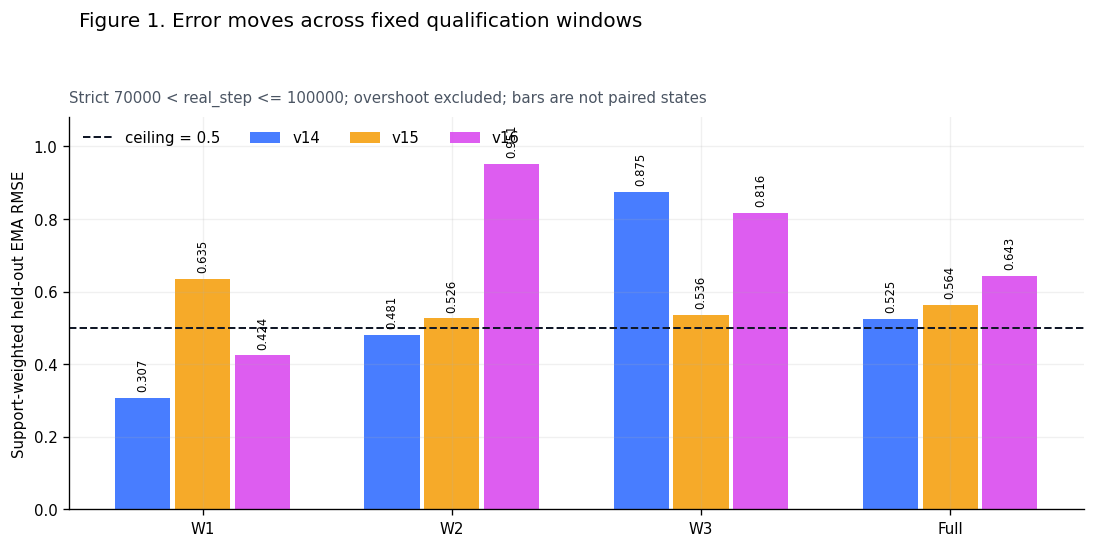

In [4]:
def summarize_calibration(version, frame, label, lower, upper):
    window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
    support = int(require_counts(window[HOLDOUT_COUNT], HOLDOUT_COUNT).sum())
    ema_rmse = pooled_rmse(window, 'actor/voc_gate_holdout_td_rmse')
    ema_sse = support * ema_rmse**2
    threshold_sse = support * RMSE_CEILING**2
    return {
        'version': version, 'window': label, 'rows': len(window), 'support': support,
        'ema_bias': pooled_mean(window, 'actor/voc_gate_holdout_td_bias', HOLDOUT_COUNT),
        'ema_mae': pooled_mean(window, 'actor/voc_gate_holdout_td_mae', HOLDOUT_COUNT),
        'ema_rmse': ema_rmse, 'online_rmse': pooled_rmse(window, 'actor/voc_holdout_td_rmse'),
        'ema_sse': ema_sse, 'threshold_sse': threshold_sse, 'excess_sse': ema_sse - threshold_sse,
        'relative_sse_reduction_to_ceiling': max(0.0, ema_sse - threshold_sse) / ema_sse,
    }

calibration_rows = []
for version, frame in canonical.items():
    calibration_rows.extend(summarize_calibration(version, frame, label, lower, upper) for label, lower, upper in WINDOWS)
    calibration_rows.append(summarize_calibration(version, frame, 'Full', LOWER_STEP, UPPER_STEP))
calibration = pd.DataFrame(calibration_rows)
expected_window_rmse = {
    ('v14', 'W1'): 0.3070468494240733, ('v14', 'W2'): 0.4805763254032396, ('v14', 'W3'): 0.8753410807478021, ('v14', 'Full'): 0.5247954789453232,
    ('v15', 'W1'): 0.6350000482991449, ('v15', 'W2'): 0.5262197892944133, ('v15', 'W3'): 0.5362964249791570, ('v15', 'Full'): 0.5637126651551874,
    ('v16', 'W1'): 0.42412219735332535, ('v16', 'W2'): 0.9513859413944138, ('v16', 'W3'): 0.8161048402729426, ('v16', 'Full'): 0.6433996228747740,
}
for row in calibration.itertuples(index=False):
    assert np.isclose(row.ema_rmse, expected_window_rmse[(row.version, row.window)], rtol=0.0, atol=1e-14)
full_sse = calibration.loc[calibration.window == 'Full'].reset_index(drop=True)
assert np.isclose(full_sse.set_index('version').loc['v16', 'ema_sse'], 3119.2117679806, rtol=0.0, atol=1e-10)
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(calibration)
    display(full_sse[['version', 'support', 'ema_rmse', 'ema_sse', 'threshold_sse', 'excess_sse', 'relative_sse_reduction_to_ceiling']])

order = ['W1', 'W2', 'W3', 'Full']
x = np.arange(len(order), dtype=float)
width = 0.24
fig, ax = plt.subplots(figsize=(9.2, 4.6))
for offset, version in zip((-width, 0.0, width), VERSIONS):
    rows = calibration.loc[calibration.version == version].set_index('window').loc[order]
    bars = ax.bar(x + offset, rows.ema_rmse, width=width * 0.92, label=version, color=COLORS[version], alpha=0.88)
    for bar, value in zip(bars, rows.ema_rmse):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.018, f'{value:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
ax.axhline(RMSE_CEILING, color='#111827', linewidth=1.2, linestyle='--', label='ceiling = 0.5')
ax.set_xticks(x, order)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Support-weighted held-out EMA RMSE')
fig.suptitle('Figure 1. Error moves across fixed qualification windows', x=0.075, y=0.98, ha='left', fontsize=12)
ax.set_title('Strict 70000 < real_step <= 100000; overshoot excluded; bars are not paired states', loc='left', color='#4B5563', fontsize=9, pad=9)
ax.legend(ncol=4, frameon=False, loc='upper left')
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()
rendered_figure_count += 1


### 3. Train/held-out moments and row-level bias/variance

The logged combined moments contain train plus holdout sufficient statistics; subtracting the held-out sums reconstructs train moments exactly. This is not a controlled generalization experiment because the gate changes the on-policy trajectory and the three runs have different supports.

For held-out EMA residuals, `MSE = within-row variance + between-row bias variance + pooled bias^2`. The decomposition is exact for the logged row aggregates. `Between-row` reflects changing row mean residuals; it is not between-seed/model variance.


,version,q_source,split,support,bias,mae,rmse
0,v14,EMA,train,54013,0.0001757239,0.2257031850,0.5865118456
1,v14,EMA,holdout,7703,-0.0173424071,0.2182068335,0.5247954789
2,v14,Online,train,54013,0.0004707586,0.2268510069,0.5867927997
3,v14,Online,holdout,7703,-0.0168082496,0.2190239446,0.5248123567
4,v15,EMA,train,57906,-0.0034510450,0.1969348060,0.4891362534
5,v15,EMA,holdout,8154,0.0058673889,0.2649639505,0.5637126652
6,v15,Online,train,57906,-0.0030080349,0.1991153192,0.4894692565
7,v15,Online,holdout,8154,0.0061157450,0.2675517220,0.5646944858
8,v16,EMA,train,52672,0.0168319447,0.2661945921,0.5999551131
9,v16,EMA,holdout,7535,0.0120960360,0.3013661225,0.6433996229


,version,ema_mse,pooled_bias,within_row_variance,between_row_bias_variance,pooled_bias_squared,within_share,between_share,bias_squared_share
0,v14,0.2754102947,-0.0173424071,0.1785494537,0.0965600819,0.0003007591,0.6483034844,0.3506044755,0.0010920401
1,v15,0.3177719689,0.0058673889,0.1892163488,0.1285211938,0.0000344263,0.5954469473,0.4044447163,0.0001083363
2,v16,0.4139630747,0.0120960360,0.2616547655,0.1521619951,0.0001463141,0.6320727174,0.3675738354,0.0003534472


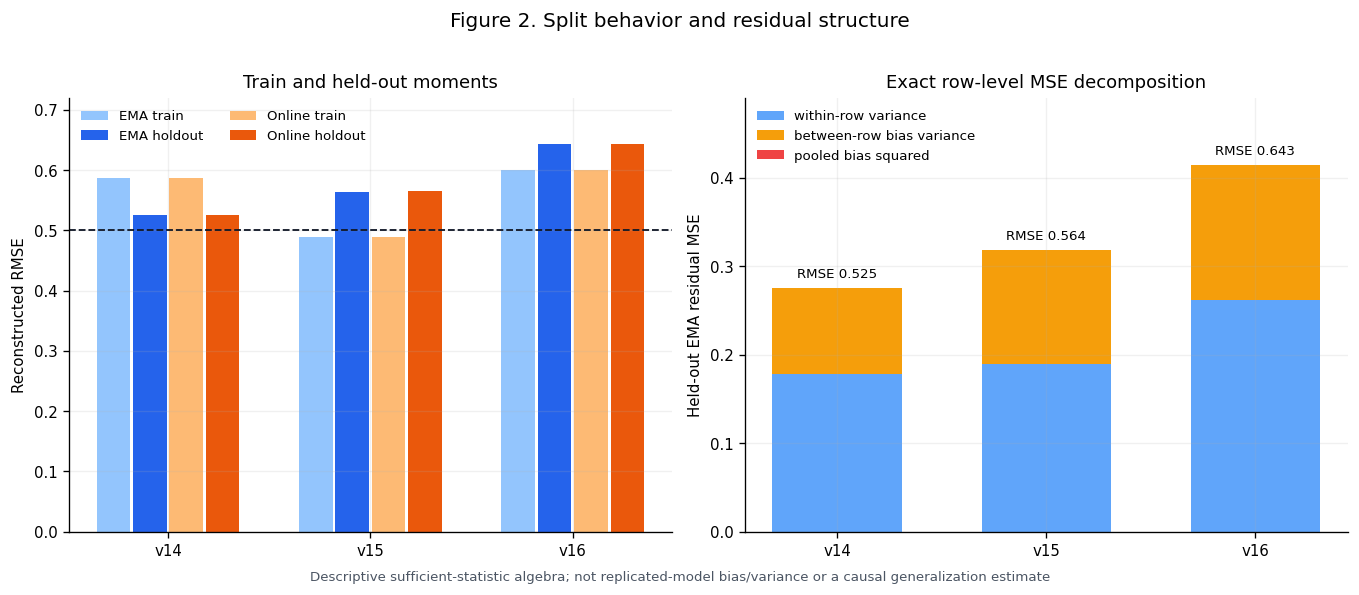

In [5]:
def reconstruct_split_moments(version, frame, source_label, prefix):
    train_n = require_counts(frame['actor/voc_continue_support'], 'train continue') + require_counts(frame['actor/voc_stop_support'], 'train stop')
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT)
    all_n = train_n + holdout_n
    all_bias = frame[f'{prefix}_td_bias'].to_numpy(dtype=np.float64)
    all_mae = frame[f'{prefix}_td_mae'].to_numpy(dtype=np.float64)
    all_rmse = frame[f'{prefix}_td_rmse'].to_numpy(dtype=np.float64)
    holdout_bias = frame[f'{prefix}_holdout_td_bias'].to_numpy(dtype=np.float64)
    holdout_mae = frame[f'{prefix}_holdout_td_mae'].to_numpy(dtype=np.float64)
    holdout_rmse = frame[f'{prefix}_holdout_td_rmse'].to_numpy(dtype=np.float64)
    train_sum = np.sum(all_n * all_bias - holdout_n * holdout_bias)
    train_abs = np.sum(all_n * all_mae - holdout_n * holdout_mae)
    train_sse = np.sum(all_n * np.square(all_rmse) - holdout_n * np.square(holdout_rmse))
    assert train_abs >= 0 and train_sse >= 0
    return [
        {'version': version, 'q_source': source_label, 'split': 'train', 'support': int(train_n.sum()), 'bias': train_sum / train_n.sum(), 'mae': train_abs / train_n.sum(), 'rmse': np.sqrt(train_sse / train_n.sum())},
        {'version': version, 'q_source': source_label, 'split': 'holdout', 'support': int(holdout_n.sum()), 'bias': np.dot(holdout_n, holdout_bias) / holdout_n.sum(), 'mae': np.dot(holdout_n, holdout_mae) / holdout_n.sum(), 'rmse': np.sqrt(np.dot(holdout_n, np.square(holdout_rmse)) / holdout_n.sum())},
    ]

split_rows = []
for version, frame in canonical.items():
    split_rows.extend(reconstruct_split_moments(version, frame, 'EMA', 'actor/voc_gate'))
    split_rows.extend(reconstruct_split_moments(version, frame, 'Online', 'actor/voc'))
split_moments = pd.DataFrame(split_rows)
expected_split_rmse = {
    ('v14', 'EMA', 'train'): 0.5865118456123475, ('v14', 'EMA', 'holdout'): 0.5247954789453232,
    ('v14', 'Online', 'train'): 0.5867927997052582, ('v14', 'Online', 'holdout'): 0.5248123566562356,
    ('v15', 'EMA', 'train'): 0.48913625344503686, ('v15', 'EMA', 'holdout'): 0.5637126651551874,
    ('v15', 'Online', 'train'): 0.48946925650925704, ('v15', 'Online', 'holdout'): 0.5646944857965209,
    ('v16', 'EMA', 'train'): 0.5999551130525911, ('v16', 'EMA', 'holdout'): 0.6433996228747740,
    ('v16', 'Online', 'train'): 0.5997760072212164, ('v16', 'Online', 'holdout'): 0.6432134673573406,
}
for row in split_moments.itertuples(index=False):
    assert np.isclose(row.rmse, expected_split_rmse[(row.version, row.q_source, row.split)], rtol=0.0, atol=1e-14), (row.version, row.q_source, row.split)

decomposition_rows = []
for version, frame in canonical.items():
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT).astype(np.float64)
    row_bias = frame['actor/voc_gate_holdout_td_bias'].to_numpy(dtype=np.float64)
    row_rmse = frame['actor/voc_gate_holdout_td_rmse'].to_numpy(dtype=np.float64)
    total_n = holdout_n.sum()
    pooled_bias = np.dot(holdout_n, row_bias) / total_n
    total_mse = np.dot(holdout_n, np.square(row_rmse)) / total_n
    within_row_variance = np.dot(holdout_n, np.square(row_rmse) - np.square(row_bias)) / total_n
    between_row_bias_variance = np.dot(holdout_n, np.square(row_bias - pooled_bias)) / total_n
    pooled_bias_squared = pooled_bias**2
    assert np.isclose(total_mse, within_row_variance + between_row_bias_variance + pooled_bias_squared, rtol=0.0, atol=1e-14)
    decomposition_rows.append({
        'version': version, 'ema_mse': total_mse, 'pooled_bias': pooled_bias,
        'within_row_variance': within_row_variance, 'between_row_bias_variance': between_row_bias_variance,
        'pooled_bias_squared': pooled_bias_squared, 'within_share': within_row_variance / total_mse,
        'between_share': between_row_bias_variance / total_mse, 'bias_squared_share': pooled_bias_squared / total_mse,
    })
error_structure = pd.DataFrame(decomposition_rows)
assert np.isclose(error_structure.set_index('version').loc['v16', 'ema_mse'], 0.4139630747154015, rtol=0.0, atol=1e-14)
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(split_moments)
    display(error_structure)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6))
x = np.arange(len(VERSIONS), dtype=float)
series = [('EMA', 'train'), ('EMA', 'holdout'), ('Online', 'train'), ('Online', 'holdout')]
series_colors = ['#93C5FD', '#2563EB', '#FDBA74', '#EA580C']
width = 0.18
for index, ((source, split), color) in enumerate(zip(series, series_colors)):
    values = [split_moments.query('version == @version and q_source == @source and split == @split').rmse.iloc[0] for version in VERSIONS]
    offset = (index - 1.5) * width
    axes[0].bar(x + offset, values, width=width * 0.92, label=f'{source} {split}', color=color)
axes[0].axhline(RMSE_CEILING, color='#111827', linestyle='--', linewidth=1.1)
axes[0].set_xticks(x, list(VERSIONS))
axes[0].set_ylim(0, 0.72)
axes[0].set_ylabel('Reconstructed RMSE')
axes[0].set_title('Train and held-out moments')
axes[0].legend(frameon=False, fontsize=8, ncol=2)

decomp = error_structure.set_index('version').loc[list(VERSIONS)]
bottom = np.zeros(len(VERSIONS))
for column, label, color in [
    ('within_row_variance', 'within-row variance', '#60A5FA'),
    ('between_row_bias_variance', 'between-row bias variance', '#F59E0B'),
    ('pooled_bias_squared', 'pooled bias squared', '#EF4444'),
]:
    values = decomp[column].to_numpy()
    axes[1].bar(x, values, bottom=bottom, label=label, color=color, width=0.62)
    bottom += values
for xpos, mse in zip(x, decomp.ema_mse):
    axes[1].text(xpos, mse + 0.012, f'RMSE {np.sqrt(mse):.3f}', ha='center', fontsize=8)
axes[1].set_xticks(x, list(VERSIONS))
axes[1].set_ylim(0, 0.49)
axes[1].set_ylabel('Held-out EMA residual MSE')
axes[1].set_title('Exact row-level MSE decomposition')
axes[1].legend(frameon=False, fontsize=8)
fig.suptitle('Figure 2. Split behavior and residual structure', fontsize=12, y=1.02)
fig.text(0.5, -0.01, 'Descriptive sufficient-statistic algebra; not replicated-model bias/variance or a causal generalization estimate', ha='center', color='#4B5563', fontsize=8)
fig.tight_layout()
plt.show()
rendered_figure_count += 1


### 4. Tail observability, composition, and update norms

`Top-k row SSE share` measures concentration across logged rows, not event-level residual quantiles. Only v14's Huber-vs-MSE pair identifies a threshold-specific event-tail energy term; v15/v16 log half-MSE, so their tail-specific identity is unavailable (`NaN`) even though row concentration remains observable.

Composition is reported rather than normalized away. In particular, W1 contains 61.33% of v16 held-out support versus 47.35% for v14 and 30.07% for v15, while v16 W3 has acceptance sign support 1 positive / 11,722 negative. Update norms are the logged raw VoC-Q total gradient norms; they are not parameter deltas. The unchanged nominal clip boundary is `0.5 * 201 * 16 = 1608`; v16 exceeds it on 35/250 all-CSV rows and 7/52 canonical rows. Cross-version norm/clipping changes are associations rather than proof of a mechanism.


,version,top_rows,sse,share_of_total_sse
0,v14,1,311.1193808693,0.1466516650
1,v14,5,1157.0343518924,0.5453887626
2,v14,10,1696.9867775455,0.7999049616
3,v15,1,342.7880044517,0.1322937490
4,v15,5,1287.2144514304,0.4967805855
5,v15,10,1798.0507853628,0.6939299982
6,v16,1,492.2218407676,0.1578032777
7,v16,5,1615.3239165497,0.5178628566
8,v16,10,2310.8044459714,0.7408296127


,version,logged_loss_definition,logged_loss,reconstructed_train_half_mse,mse_minus_2huber,tail_energy_fraction
0,v14,Huber beta=1,0.1242177419,0.1721628949,0.0958903061,0.2784871448
1,v15,half-MSE,0.1197900774,0.1197900765,NaN,NaN
2,v16,half-MSE,0.1798656289,0.1798656294,NaN,NaN


,version,train_continue,train_stop,train_stop_fraction,holdout_continue,holdout_stop,holdout_stop_fraction,accept_positive,accept_negative,accept_positive_fraction,W1_support_share,W2_support_share,W3_support_share,W3_accept_positive,W3_accept_negative
0,v14,28219,25794,0.4775517005,4016,3687,0.4786446839,32458,29257,0.5259337276,0.4734519019,0.3226015838,0.2039465143,1023,11408
1,v15,31359,26547,0.4584499016,4365,3789,0.4646799117,36718,29339,0.5558532782,0.3007113073,0.4303409370,0.2689477557,6916,10701
2,v16,26897,25775,0.4893491798,3858,3677,0.4879893829,30798,29408,0.5115437000,0.6132714001,0.1927007299,0.1940278699,1,11722


,version,nominal_clip_boundary,all_csv_rows,all_csv_boundary_exceedances,canonical_rows,canonical_boundary_exceedances
0,v14,1608.0000000000,204,0,63,0
1,v15,1608.0000000000,149,1,58,0
2,v16,1608.0000000000,250,35,52,7


,version,window,updates,train_support,train_support_per_update,logged_q_loss,reconstructed_train_half_mse,q_raw_norm_mean,q_raw_norm_median,q_raw_norm_p95,q_raw_norm_max
0,v14,W1,32,26203,818.8437500000,0.0302336039,0.0320744263,43.7297306061,35.3293666840,90.1979179382,129.2094879150
1,v14,W2,19,16949,892.0526315789,0.0725517989,0.0957707799,106.7384317298,110.8502883911,209.8414901733,289.9289245605
2,v14,W3,12,10861,905.0833333333,0.4315883740,0.6293499035,391.3856321971,313.6181488037,864.6222351074,886.3068847656
3,v14,Full,63,54013,857.3492063492,0.1242177419,0.1721628949,128.9525264861,62.3866691589,443.1804840088,886.3068847656
4,v15,W1,19,17739,933.6315789474,0.1709406693,0.1709406684,218.9079712316,132.3802490234,753.0468688965,767.4251708984
5,v15,W2,26,24741,951.5769230769,0.1041303743,0.1041303740,185.8801991389,119.6521339417,483.4906158447,802.5406494141
6,v15,W3,13,15426,1186.6153846154,0.0860857059,0.0860857041,119.5373567434,138.9091644287,191.8820678711,220.8452606201
7,v15,Full,58,57906,998.3793103448,0.1197900774,0.1197900765,181.8296942875,131.7394409180,537.2278793335,802.5406494141
8,v16,W1,32,32171,1005.3437500000,0.0595933142,0.0595933128,523.1005339622,345.3625793457,1637.2273437500,1712.2170410156
9,v16,W2,10,10240,1024.0000000000,0.2386107571,0.2386107560,514.8573974609,419.7950134277,1048.7463592529,1339.7142333984


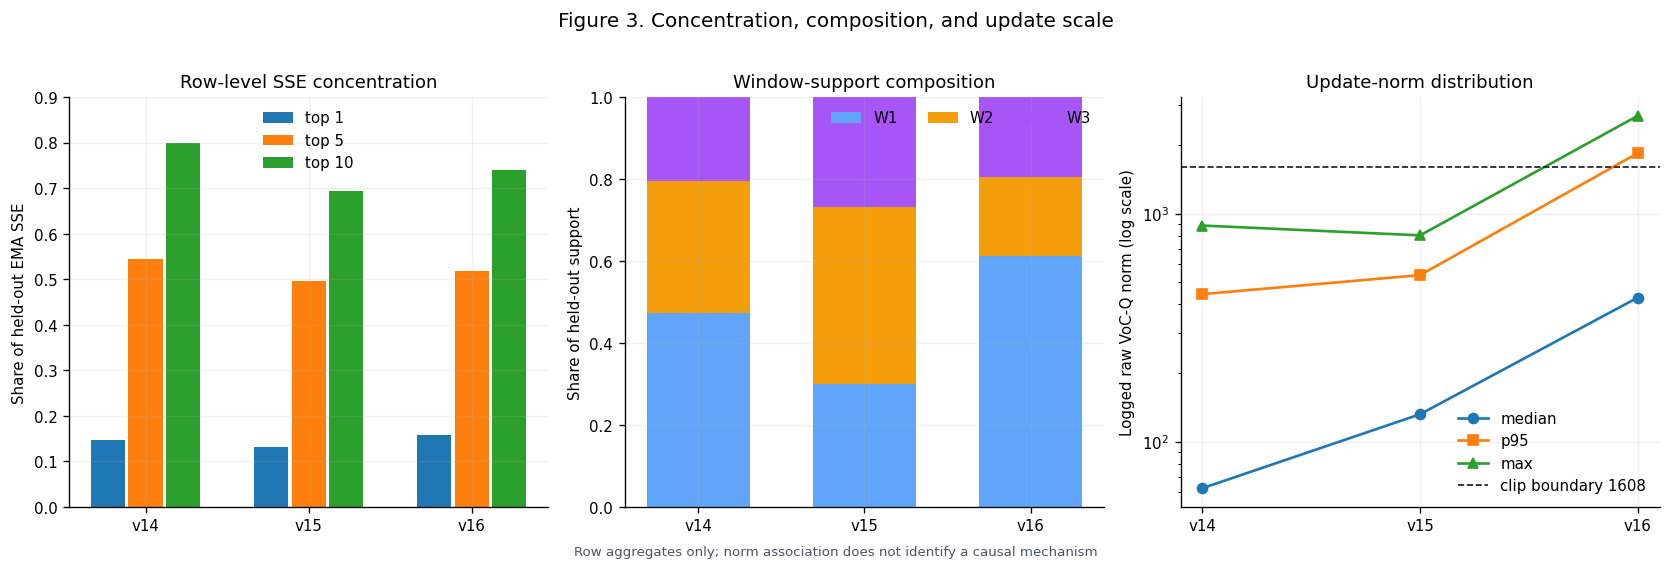

In [6]:
concentration_rows, tail_rows, composition_rows, regime_rows, clip_rows = [], [], [], [], []
VOC_Q_CLIP_BOUNDARY = 0.5 * 201 * 16
assert VOC_Q_CLIP_BOUNDARY == 1608.0
for version, frame in canonical.items():
    full_frame = frames[version]
    clip_rows.append({
        'version': version, 'nominal_clip_boundary': VOC_Q_CLIP_BOUNDARY,
        'all_csv_rows': len(full_frame),
        'all_csv_boundary_exceedances': int((full_frame['actor/voc_total_norm'] > VOC_Q_CLIP_BOUNDARY).sum()),
        'canonical_rows': len(frame),
        'canonical_boundary_exceedances': int((frame['actor/voc_total_norm'] > VOC_Q_CLIP_BOUNDARY).sum()),
    })
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT).astype(np.float64)
    row_rmse = frame['actor/voc_gate_holdout_td_rmse'].to_numpy(dtype=np.float64)
    row_sse = pd.Series(holdout_n * np.square(row_rmse)).sort_values(ascending=False)
    for top_k in (1, 5, 10):
        concentration_rows.append({
            'version': version, 'top_rows': top_k, 'sse': float(row_sse.head(top_k).sum()),
            'share_of_total_sse': float(row_sse.head(top_k).sum() / row_sse.sum()),
        })
    train_n = require_counts(frame['actor/voc_continue_support'], 'train continue') + require_counts(frame['actor/voc_stop_support'], 'train stop')
    all_n = train_n + holdout_n.astype(np.int64)
    train_sse_rows = (
        all_n * np.square(frame['actor/voc_td_rmse'].to_numpy(dtype=np.float64))
        - holdout_n * np.square(frame['actor/voc_holdout_td_rmse'].to_numpy(dtype=np.float64))
    )
    train_half_mse = float(train_sse_rows.sum() / (2.0 * train_n.sum()))
    logged_loss = float(np.dot(train_n, frame['actor/voc_q_loss'].to_numpy(dtype=np.float64)) / train_n.sum())
    tail_rows.append({
        'version': version, 'logged_loss_definition': 'Huber beta=1' if version == 'v14' else 'half-MSE',
        'logged_loss': logged_loss, 'reconstructed_train_half_mse': train_half_mse,
        'mse_minus_2huber': 2.0 * (train_half_mse - logged_loss) if version == 'v14' else np.nan,
        'tail_energy_fraction': (train_half_mse - logged_loss) / train_half_mse if version == 'v14' else np.nan,
    })
    train_continue = int(require_counts(frame['actor/voc_continue_support'], 'train continue').sum())
    train_stop = int(require_counts(frame['actor/voc_stop_support'], 'train stop').sum())
    holdout_continue = int(require_counts(frame['actor/voc_holdout_continue_support'], 'holdout continue').sum())
    holdout_stop = int(require_counts(frame['actor/voc_holdout_stop_support'], 'holdout stop').sum())
    accept_positive = int(require_counts(frame[f'{GATE_PREFIX}_delta_q_positive_count'], 'accept positive').sum())
    accept_negative = int(require_counts(frame[f'{GATE_PREFIX}_delta_q_negative_count'], 'accept negative').sum())
    composition = {
        'version': version, 'train_continue': train_continue, 'train_stop': train_stop,
        'train_stop_fraction': train_stop / (train_continue + train_stop),
        'holdout_continue': holdout_continue, 'holdout_stop': holdout_stop,
        'holdout_stop_fraction': holdout_stop / (holdout_continue + holdout_stop),
        'accept_positive': accept_positive, 'accept_negative': accept_negative,
        'accept_positive_fraction': accept_positive / (accept_positive + accept_negative),
    }
    for label, lower, upper in WINDOWS:
        window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
        composition[f'{label}_support_share'] = require_counts(window[HOLDOUT_COUNT], HOLDOUT_COUNT).sum() / holdout_n.sum()
        if label == 'W3':
            composition['W3_accept_positive'] = int(require_counts(window[f'{GATE_PREFIX}_delta_q_positive_count'], 'W3 accept positive').sum())
            composition['W3_accept_negative'] = int(require_counts(window[f'{GATE_PREFIX}_delta_q_negative_count'], 'W3 accept negative').sum())
    composition_rows.append(composition)
    work = frame.copy()
    work['train_count'] = train_n
    work['train_half_mse'] = train_sse_rows / (2.0 * train_n)
    assert (work['actor/voc_optimizer_stepped'] == 1).all()
    assert (work['actor/voc_gate_optimizer_stepped'] == 0).all()
    assert (work['actor/voc_gate_projection_post_error_norm'] == 0).all()
    assert (work['actor/voc_update_count'] == work['actor/voc_ema_gate_update_count']).all()
    assert (work['actor/voc_update_count'] == work['actor/voc_gate_update_count']).all()
    assert np.all(np.diff(work['actor/voc_update_count']) == 1)
    for label, lower, upper in (*WINDOWS, ('Full', LOWER_STEP, UPPER_STEP)):
        window = work.loc[(work.real_step > lower) & (work.real_step <= upper)]
        window_support = int(window.train_count.sum())
        updates = int(window['actor/voc_optimizer_stepped'].sum())
        regime_rows.append({
            'version': version, 'window': label, 'updates': updates, 'train_support': window_support,
            'train_support_per_update': window_support / updates,
            'logged_q_loss': float(np.dot(window.train_count, window['actor/voc_q_loss']) / window_support),
            'reconstructed_train_half_mse': float(np.dot(window.train_count, window.train_half_mse) / window_support),
            'q_raw_norm_mean': float(window['actor/voc_total_norm'].mean()),
            'q_raw_norm_median': float(window['actor/voc_total_norm'].median()),
            'q_raw_norm_p95': float(window['actor/voc_total_norm'].quantile(0.95)),
            'q_raw_norm_max': float(window['actor/voc_total_norm'].max()),
        })

concentration = pd.DataFrame(concentration_rows)
tail_observability = pd.DataFrame(tail_rows)
composition = pd.DataFrame(composition_rows)
regimes = pd.DataFrame(regime_rows)
clip_summary = pd.DataFrame(clip_rows)
full_regimes = regimes.loc[regimes.window == 'Full'].reset_index(drop=True)
expected_top10 = {'v14': 0.7999049615724924, 'v15': 0.6939299981526046, 'v16': 0.7408296126900790}
for version, expected in expected_top10.items():
    actual = concentration.query('version == @version and top_rows == 10').share_of_total_sse.iloc[0]
    assert np.isclose(actual, expected, rtol=0.0, atol=1e-14)
assert np.isclose(full_regimes.set_index('version').loc['v16', 'q_raw_norm_median'], 428.2610778808594, rtol=0.0, atol=1e-12)
assert np.isclose(full_regimes.set_index('version').loc['v16', 'q_raw_norm_p95'], 1842.8370300292963, rtol=0.0, atol=1e-10)
assert clip_summary.set_index('version')[['all_csv_boundary_exceedances', 'canonical_boundary_exceedances']].to_dict('index') == {
    'v14': {'all_csv_boundary_exceedances': 0, 'canonical_boundary_exceedances': 0},
    'v15': {'all_csv_boundary_exceedances': 1, 'canonical_boundary_exceedances': 0},
    'v16': {'all_csv_boundary_exceedances': 35, 'canonical_boundary_exceedances': 7},
}
assert composition.set_index('version').loc['v16', ['W3_accept_positive', 'W3_accept_negative']].astype(int).tolist() == [1, 11722]
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(concentration)
    display(tail_observability)
    display(composition)
    display(clip_summary)
    display(regimes)

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.4))
x = np.arange(len(VERSIONS), dtype=float)
for index, top_k in enumerate((1, 5, 10)):
    values = [concentration.query('version == @version and top_rows == @top_k').share_of_total_sse.iloc[0] for version in VERSIONS]
    axes[0].bar(x + (index - 1) * 0.23, values, width=0.21, label=f'top {top_k}')
axes[0].set_xticks(x, list(VERSIONS))
axes[0].set_ylim(0, 0.9)
axes[0].set_ylabel('Share of held-out EMA SSE')
axes[0].set_title('Row-level SSE concentration')
axes[0].legend(frameon=False)

bottom = np.zeros(len(VERSIONS))
for label, color in zip(('W1', 'W2', 'W3'), ('#60A5FA', '#F59E0B', '#A855F7')):
    values = composition.set_index('version').loc[list(VERSIONS), f'{label}_support_share'].to_numpy()
    axes[1].bar(x, values, bottom=bottom, width=0.62, label=label, color=color)
    bottom += values
axes[1].set_xticks(x, list(VERSIONS))
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Share of held-out support')
axes[1].set_title('Window-support composition')
axes[1].legend(frameon=False, ncol=3)

norm_table = full_regimes.set_index('version').loc[list(VERSIONS)]
for column, label, marker in [('q_raw_norm_median', 'median', 'o'), ('q_raw_norm_p95', 'p95', 's'), ('q_raw_norm_max', 'max', '^')]:
    axes[2].plot(x, norm_table[column], marker=marker, linewidth=1.6, label=label)
axes[2].axhline(VOC_Q_CLIP_BOUNDARY, color='#111827', linestyle='--', linewidth=1.0, label='clip boundary 1608')
axes[2].set_xticks(x, list(VERSIONS))
axes[2].set_yscale('log')
axes[2].set_ylabel('Logged raw VoC-Q norm (log scale)')
axes[2].set_title('Update-norm distribution')
axes[2].legend(frameon=False)
fig.suptitle('Figure 3. Concentration, composition, and update scale', fontsize=12, y=1.02)
fig.text(0.5, -0.01, 'Row aggregates only; norm association does not identify a causal mechanism', ha='center', color='#4B5563', fontsize=8)
fig.tight_layout()
plt.show()
rendered_figure_count += 1


## Evidence, causal limits, and ranked next-experiment hypotheses

### Frozen evidence

1. **The hard-gate outcomes are arithmetically determined.** V14 and v15 each fail the held-out EMA RMSE ceiling. V16 fails both that ceiling (0.6433996229) and trailing-five denominator validity (five zero-positive endpoints). The latter is not a negative-gap run: its 43 defined endpoints are positive and maximum negative run is zero.
2. **Error is redistributed in time.** V16 W1 is below 0.5, but W2/W3 are 0.9514/0.8161. Its W1-heavy support composition (61.33%) masks rather than eliminates the late-window deterioration in the pooled value. No post-hoc window reweighting is permitted.
3. **Train and held-out move together for v16, unlike v14→v15.** V16 EMA train/held-out RMSE are 0.6000/0.6434. V15's corresponding values are 0.4891/0.5637. These differences combine algorithm, trajectory, row cadence, support, and states.
4. **Pooled bias is small relative to error.** V16 pooled bias is 0.01210 while RMSE is 0.64340; within-row variance and between-row bias variance contribute 63.21% and 36.76% of MSE. A single global bias adjustment cannot account for most observed MSE.
5. **V16 has larger logged raw Q norms, more clipping, and concentrated row SSE.** Canonical norm median/p95/max are 428.26/1842.84/2687.01 versus 131.74/537.23/802.54 for v15. The nominal 1,608 boundary is exceeded on 35/250 all-CSV and 7/52 canonical v16 rows, compared with 1/149 and 0/58 for v15. V16's top 10 rows carry 74.08% of SSE. These are associations, not proof that common-mode reconstruction caused any pattern.
6. **Late sign composition collapses on the positive side.** V16 W3 acceptance support is 1 positive / 11,722 negative; the first invalid trailing-five endpoint is 95344. This establishes the denominator failure, not why the policy/support moved there.

### What is not identified

There is one seed and one separately generated on-policy run per version, no paired states, no counterfactual action residuals, no event-level residual samples, and no factorial isolation of loss versus reconstruction. Therefore this notebook does **not** estimate a treatment effect, identify a unique root cause, predict a future pass, or authorize a retry/primary/fixed evaluation. EMA lag is deprioritized descriptively because v16 online and EMA held-out RMSE differ by only 0.000186; it is not experimentally ruled out.

### Ranked V17 model candidates — hypotheses only, no implementation or pass prediction

1. **Beta-1 Huber with retained common-mode reconstruction (highest-ranked immediate-successor hypothesis).** V17 lineage begins at v16/schema 9: common-mode reconstruction is retained and exactly one training semantic changes, from half-MSE to beta-1 Huber. This fills the missing cell in the 2×2 loss-by-reconstruction comparison. It changes two semantics only relative to v15, not relative to v16. Motivation: v14's Huber run has no raw-Q boundary exceedance, while v16 retains half-MSE and records 35/250 all-CSV exceedances plus worse train/held-out MSE. Beta-1 Huber caps each example's residual-loss slope beyond beta; it does **not** promise that an aggregate raw gradient norm or clipping frequency will fall. Falsifier: the preregistered window/RMSE/support pattern persists under the one-semantic successor, whether or not aggregate norms or clipping change.
2. **Explicit orthonormal mean/difference-coordinate Adam.** Motivation: schema 9 makes raw-head mean learnable while coordinatewise Adam still operates on the two action-row coordinates; explicit orthonormal mean/difference coordinates could separate common and action-difference optimizer state while preserving represented Q values. The CSV does not observe optimizer-coordinate causality. Falsifier: separated coordinate telemetry/state leaves norm, W2/W3 error, and sign support unchanged.

### Acceptance and monitoring requirement — not a model candidate

**Do not relax signed-support accounting.** V16 W3 acceptance support is 1 positive / 11,722 negative, and its last five trailing endpoints have zero positive support. Any successor must retain the same positive/negative counts, endpoint validity rule, and trailing-five gate: zero positive support stays undefined/invalid, never zero or nonnegative. Restored sign support would be an observed outcome under a candidate, not a separately ranked mechanism; denominator relaxation and post-hoc row removal remain prohibited.

### Open evidence need — not a model candidate

**Add event-level residual telemetry before selecting further tail controls.** V16's top 10 rows carry 74.08% of held-out EMA SSE, but CSV row aggregates cannot reveal event-tail quantiles or connect individual residuals to aggregate raw norms. This telemetry would discriminate later hypotheses; it does not change acceptance, identify a cause by itself, or constitute a peer V17 model candidate.

**Deprioritized:** a global bias correction (pooled bias is tiny), an EMA-tau-only change (online/EMA near-equality), and any post-hoc window/support reweighting or threshold relaxation. The ranking organizes falsifiable follow-up questions; it is not a design authorization.


In [7]:
assert rendered_figure_count == 3
audit = {
    'production_python': {'version': platform.python_version(), 'executable': str(Path(sys.executable).resolve())},
    'protocol_population': '70000 < real_step <= 100000',
    'actor_csv_sha256': {version: spec['actor_sha256'] for version, spec in VERSIONS.items()},
    'model_csv_sha256': {version: spec['model_sha256'] for version, spec in VERSIONS.items()},
    'canonical_population': {version: spec['canonical'] for version, spec in VERSIONS.items()},
    'heldout_ema_rmse': {version: authoritative[version]['heldout_ema_rmse'] for version in VERSIONS},
    'csv_observable_hard_gate_failures': failure_sets,
    'v16_zero_positive_trailing_five_endpoints': trailing_results['v16'].loc[trailing_results['v16'].positive_n == 0, 'real_step'].astype(int).tolist(),
    'v16_W3_acceptance_sign_support': {'positive': int(composition.set_index('version').loc['v16', 'W3_accept_positive']), 'negative': int(composition.set_index('version').loc['v16', 'W3_accept_negative'])},
    'v16_raw_q_boundary_exceedances': {'boundary': VOC_Q_CLIP_BOUNDARY, 'all_csv': '35/250', 'canonical': '7/52'},
    'embedded_figures': rendered_figure_count,
    'causal_effect_estimated': False,
    'pass_prediction_made': False,
    'v17_implementation_performed': False,
}
assert audit['production_python']['version'] == '3.10.21'
assert audit['v16_zero_positive_trailing_five_endpoints'] == [95344, 96368, 97392, 98416, 99408]
assert audit['v16_W3_acceptance_sign_support'] == {'positive': 1, 'negative': 11722}
print(json.dumps(audit, indent=2, sort_keys=True))


{
  "actor_csv_sha256": {
    "v14": "6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8",
    "v15": "359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d67800f0308f448e341",
    "v16": "45da4532357f5f150fad15c47bf1cdbb5ec52738ff3a68678afb5dca73ed20d5"
  },
  "canonical_population": {
    "v14": {
      "first": 70032,
      "last": 99376,
      "overshoot": [
        100112
      ],
      "rows": 63,
      "support": 7703
    },
    "v15": {
      "first": 70240,
      "last": 99920,
      "overshoot": [
        100736
      ],
      "rows": 58,
      "support": 8154
    },
    "v16": {
      "first": 70032,
      "last": 99408,
      "overshoot": [
        100432
      ],
      "rows": 52,
      "support": 7535
    }
  },
  "causal_effect_estimated": false,
  "csv_observable_hard_gate_failures": {
    "v14": [
      "heldout_ema_rmse"
    ],
    "v15": [
      "heldout_ema_rmse"
    ],
    "v16": [
      "trailing_denominators_valid",
      "heldout_ema_rmse"
    ]
  },
  "e

## Takeaways

- Exact bytes and the strict population reproduce v14/v15/v16 held-out EMA RMSE at 0.5247954789, 0.5637126652, and 0.6433996229.
- V16 also has five undefined trailing-five endpoints caused by zero positive support; they cannot be treated as zero or nonnegative gaps.
- V16's dominant descriptive signals are W2/W3 error, 35/250 all-CSV and 7/52 canonical raw-Q boundary exceedances, row-SSE concentration, W3 sign support 1/11,722, and late positive-support loss. The available runs do not identify which mechanism caused them.
- The two ranked model candidates above are falsifiable hypotheses only; signed-support accounting remains an acceptance/monitoring requirement and event-level telemetry remains an open evidence need. This notebook makes no pass prediction and performs no v17 implementation, launch, evaluation, fixed evaluation, retry, or rescue.
